# IAPR 2026 — Final Project Report
## UNO Vision Challenge: Recovering Game State from Tabletop Snapshots

**Group:** `<group_id>` — `<kaggle_group_name>`

**Members:**
- `<Name 1>` — SCIPER `<xxxxxx>`
- `<Name 2>` — SCIPER `<xxxxxx>`
- `<Name 3>` — SCIPER `<xxxxxx>`

---

> **How to read this report.** The notebook is organised as an executable
> walkthrough of our solution. Every section pairs a short written justification
> with the code that produced the figures. Re-running the notebook top-to-bottom
> regenerates every plot from the model checkpoints in `project/models/`. The
> exact Kaggle submission CSV is produced by running `python main.py` from the
> repository root.

## 1. Problem statement and approach

> *Write here:* one paragraph restating the task in our own words (per-image
> recovery of center card, active player, four hands), the dataset constraints
> (no external data, no pretrained weights, ≤12M params per model, fixed
> player geometry), and a one-sentence preview of our pipeline.

### 1.1 Pipeline overview

Our solution is a four-stage pipeline:

1. **Segmentation.** A small U-Net produces a per-pixel card-foreground
   probability map.
2. **Instance extraction.** Connected components are split into per-card
   instance masks (with controlled mask dilation) and bounding boxes.
3. **Classification.** A masked 4-channel ResNet-18 (RGB + mask channel)
   classifies each crop into one of 54 UNO card types.
4. **Game-state assembly.** Boxes are assigned to a region (center, p1..p4)
   by geometry. The active player is recovered by detecting the round token.

> *Write here:* justify the high-level decomposition. Why two models instead
> of an end-to-end detector? What is the trade-off?

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Notebook lives at the repo root; make sure `src` is importable from there.
REPO_ROOT = Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.inference import InferenceConfig, load_engine, predict_from_path
from src.report_viz import (
    plot_pipeline_stages,
    plot_region_layout,
    plot_confidence_histogram,
    plot_class_frequency,
    plot_card_count_per_region,
    plot_qualitative_grid,
)
from src.submission import write_submission, validate_row, CSV_COLUMNS

MODELS_DIR = REPO_ROOT / "models"
CHALLENGE_DIR = REPO_ROOT / "data" / "iapr-26-uno-vision-challenge"
TRAIN_DIR = CHALLENGE_DIR / "train_images"
TEST_DIR = CHALLENGE_DIR / "test_images"
TRAIN_CSV = CHALLENGE_DIR / "train.csv"

## 2. Compliance checks (R1–R6)

> *Write here:* state explicitly that our pipeline uses no external datasets
> and no pretrained weights, that the test set is only used for inference, and
> that both models fit under the 12M-parameter cap. Loading the engine below
> prints the trainable parameter count for each model and asserts the cap.

In [2]:
engine = load_engine(MODELS_DIR, config=InferenceConfig(), verbose=True)
print(f"\nClasses ({len(engine.class_names)}): {list(engine.class_names)}")

[compliance] SceneUNetSmall (segmenter): 1,928,417 trainable params
[compliance] CardClassifier[resnet18_small]: 9,853,134 trainable params
[engine] device=cuda | classes=54 | card_img_size=160 | seg_threshold=0.5

Classes (54): [np.str_('b_0'), np.str_('b_1'), np.str_('b_2'), np.str_('b_3'), np.str_('b_4'), np.str_('b_5'), np.str_('b_6'), np.str_('b_7'), np.str_('b_8'), np.str_('b_9'), np.str_('b_draw_2'), np.str_('b_reverse'), np.str_('b_skip'), np.str_('draw_4'), np.str_('g_0'), np.str_('g_1'), np.str_('g_2'), np.str_('g_3'), np.str_('g_4'), np.str_('g_5'), np.str_('g_6'), np.str_('g_7'), np.str_('g_8'), np.str_('g_9'), np.str_('g_draw_2'), np.str_('g_reverse'), np.str_('g_skip'), np.str_('r_0'), np.str_('r_1'), np.str_('r_2'), np.str_('r_3'), np.str_('r_4'), np.str_('r_5'), np.str_('r_6'), np.str_('r_7'), np.str_('r_8'), np.str_('r_9'), np.str_('r_draw_2'), np.str_('r_reverse'), np.str_('r_skip'), np.str_('wild'), np.str_('y_0'), np.str_('y_1'), np.str_('y_2'), np.str_('y_3'), np.s

## 3. Stage 1 — Segmentation

> *Write here:*
> - Architecture choice: small U-Net (≈2M params), 256-px letterboxed input,
>   binary cross-entropy + Dice loss (whichever was used).
> - Training data: which images, which augmentations.
> - Why we **dilate** the predicted mask after thresholding (recent commit):
>   under-segmentation cropped corners of the card art and hurt the classifier.
> - Trade-off: dilation too high → adjacent cards merge → instance split fails.

### 3.1 Segmenter qualitative behaviour

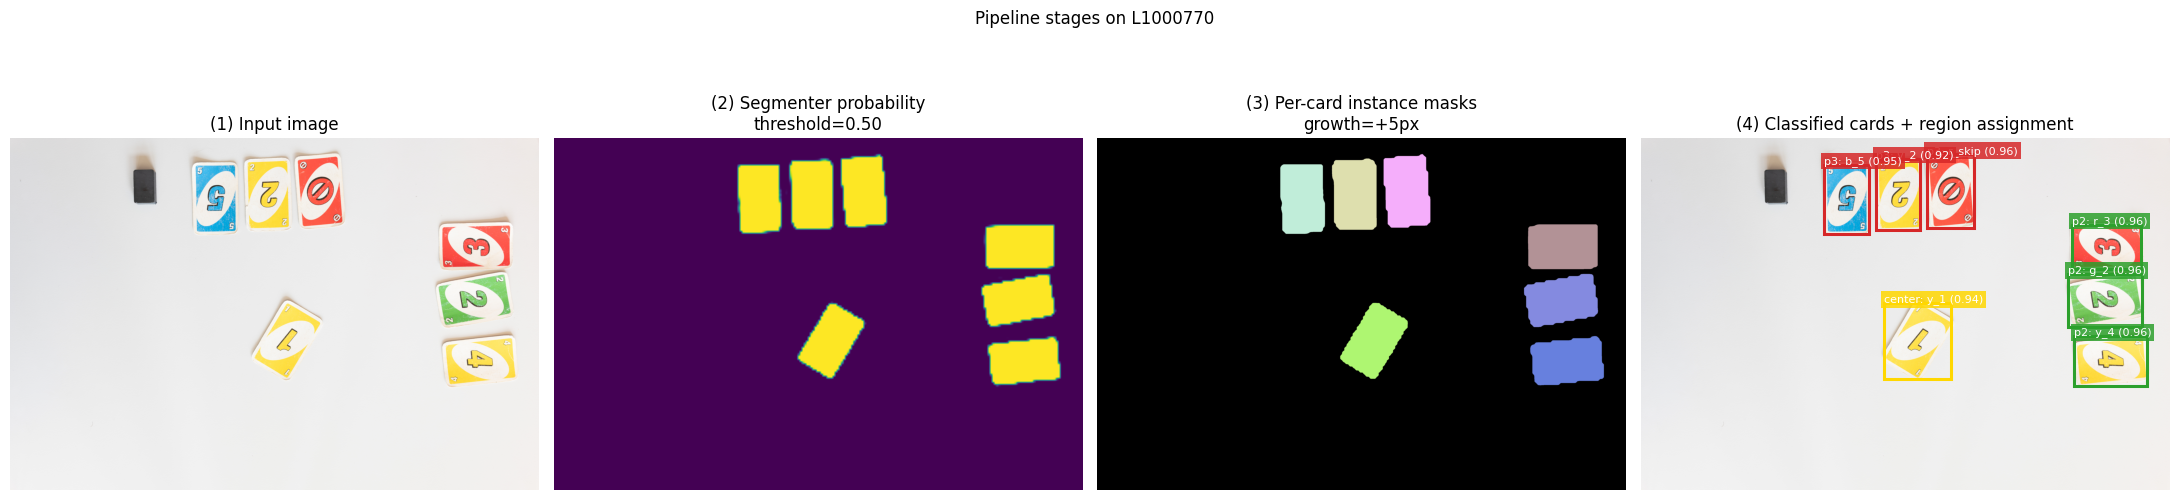

In [3]:
# Pick a representative training image (replace the id with anything visual).
demo_id = "L1000770"
demo_path = TRAIN_DIR / f"{demo_id}.jpg"
demo_state = predict_from_path(engine, demo_path)
demo_img = cv2.imread(str(demo_path), cv2.IMREAD_COLOR)

plot_pipeline_stages(engine, demo_img, demo_state.cards, title=f"Pipeline stages on {demo_id}")

> *Comment here:* describe what each stage produces on this example, in 3–4
> lines. Mention the dilation behaviour visible in stage (3).

## 4. Stage 2 — Card classification

> *Write here:*
> - Compact ResNet-18 variant (`resnet18_small`, ~9.85M params, stem_width=60),
>   randomly initialised (R2).
> - Why 4-channel input (RGB + binary mask): forces the network to ignore
>   background pixels that vary with the table/hand.
> - Three-stage curriculum: reference cards → augmented compositions →
>   real scene crops with manual masks (see `project/models/.../config.json`).
> - Best epoch + validation accuracy (taken from the saved config).

### 4.1 Class names handled by the classifier

In [4]:
import json
from src.shared.model_paths import resolve_classifier_bundle
bundle = resolve_classifier_bundle(MODELS_DIR)
classifier_cfg = json.loads(Path(bundle["config_path"]).read_text(encoding="utf-8"))
print(f"Architecture: {classifier_cfg.get('architecture')}")
print(f"Trainable params: {classifier_cfg.get('trainable_params'):,}")
print(f"Best val accuracy: {classifier_cfg.get('best_val_accuracy'):.4f} "
      f"@ epoch {classifier_cfg.get('best_epoch')} of {classifier_cfg.get('best_stage')}")
print(f"Validation samples: {classifier_cfg.get('validation_samples'):,}")

Architecture: resnet18_small
Trainable params: 9,853,134
Best val accuracy: 0.8739 @ epoch 90 of stage3_scene_manual_masks
Validation samples: 21,188


## 5. Stage 3 — Region assignment (geometry)

> *Write here:* per R6, player positions are fixed (p1=bottom, p2=right,
> p3=top, p4=left). We map each box centroid to the nearest player edge,
> with a central rectangle reserved for the table card. No learning involved.

The diagram below makes the partition explicit.

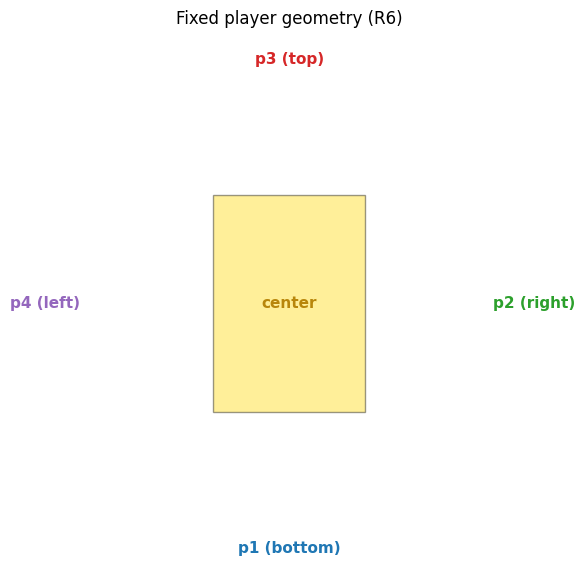

In [5]:
plot_region_layout()

## 6. Stage 4 — Active player detection

> **Status:** the token detector is implemented in `src/active_player.py` and
> is owned by `<teammate>`. Replace the stub there before generating the final
> submission.

> *Write here once the detector lands:*
> - Color space and threshold range used to isolate the token.
> - Geometric filters (area, circularity).
> - How the token centroid is mapped to one of p1..p4.
> - Failure modes observed (occluded token, glare, similar-coloured cards).

## 7. Quantitative evaluation

> *Write here:* describe the metric we use to score ourselves locally — bag
> F1 per player + center accuracy, averaged. Make clear this is the same
> form as the official Kaggle metric (or note where it differs).

### 7.1 Held-out benchmark on labelled training images

We re-use `run_labeled_benchmark` from `src/test_classifier_CNN/pipeline.py`,
which evaluates the full pipeline on the official `train.csv` rows.

In [6]:
from src.test_classifier_CNN.pipeline import (
    TestPipelineConfig,
    initialize_test_pipeline,
    run_labeled_benchmark,
)

# Use a smaller subset for the notebook so it runs in a few minutes; remove
# `eval_max_images` for the full reproduction on the TA's machine.
test_state = initialize_test_pipeline(TestPipelineConfig(image_source="train_image"))
benchmark = run_labeled_benchmark(test_state, benchmark_config={
    "eval_max_images": 60,
    "eval_random_subset": True,
    "eval_seed": 42,
    "worst_k": 4,
    "top_k": 4,
})

ModuleNotFoundError: No module named 'src.test_classifier_CNN'

> *Comment here:* summarise the numbers. Where do we win? Where do we lose?
> Tie the failures to specific pipeline stages.

## 8. Diagnostic plots over the full test set

We run the pipeline on every test image and aggregate the predictions for
sanity-checking before submitting.

In [ ]:
from tqdm import tqdm

test_paths = sorted(TEST_DIR.glob("*.jpg"))
test_states = [predict_from_path(engine, p) for p in tqdm(test_paths, desc="test inference")]
all_test_preds = [pred for state in test_states for pred in state.cards]
print(f"Predicted {len(all_test_preds)} cards across {len(test_states)} test images.")

test inference: 100%|██████████| 159/159 [01:11<00:00,  2.22it/s]

Predicted 1179 cards across 159 test images.


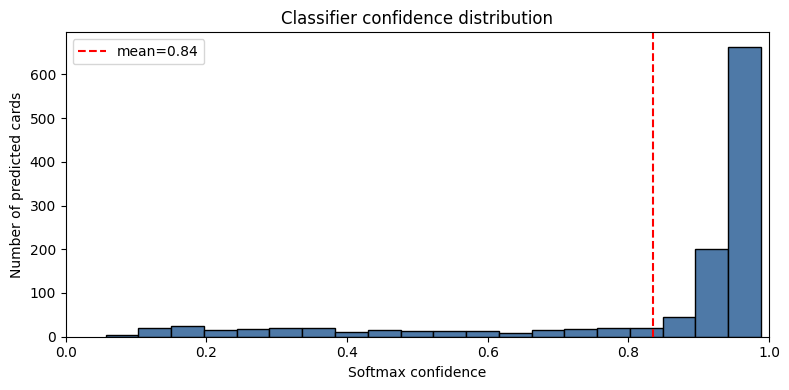

In [ ]:
plot_confidence_histogram(all_test_preds)

> *Comment:* what does the shape tell us about the classifier's calibration?

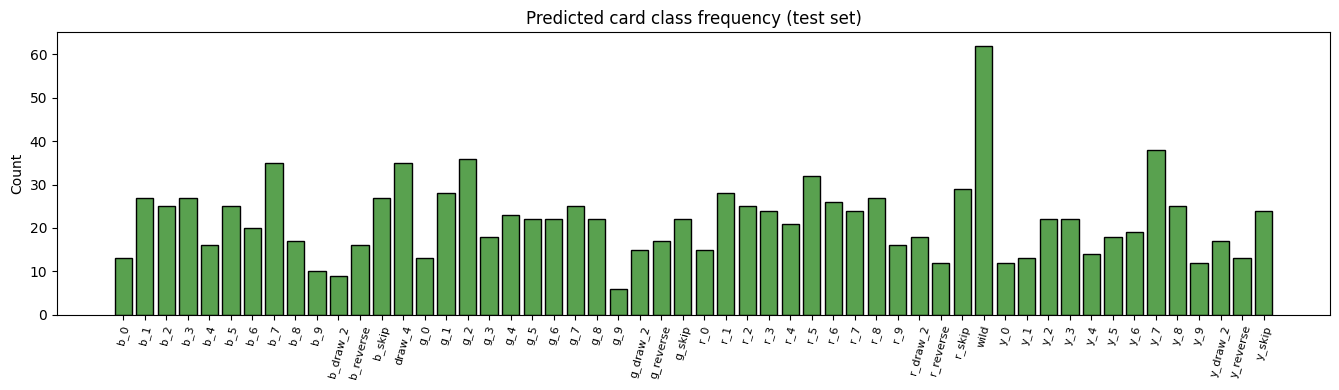

In [ ]:
plot_class_frequency(all_test_preds)

> *Comment:* flag any obvious over- or under-represented classes.

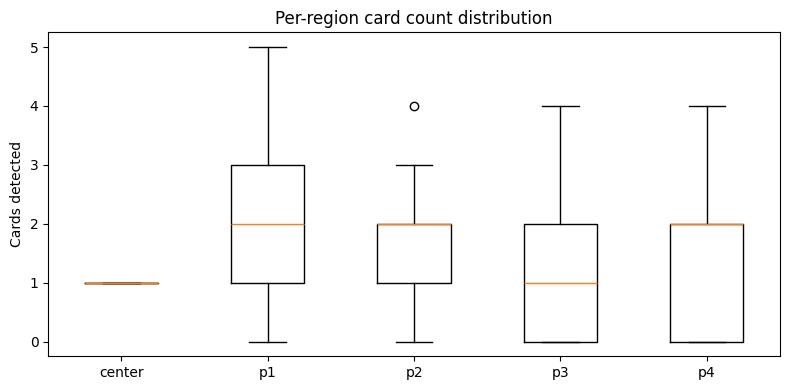

In [ ]:
plot_card_count_per_region(test_states)

> *Comment:* the center should sit on 0/1 — anything else indicates the
> region rectangle catches a player's first card. p1..p4 give a sanity check
> on segmenter recall.

## 9. Qualitative gallery

Sampled successes and (interesting) failures from the test set.

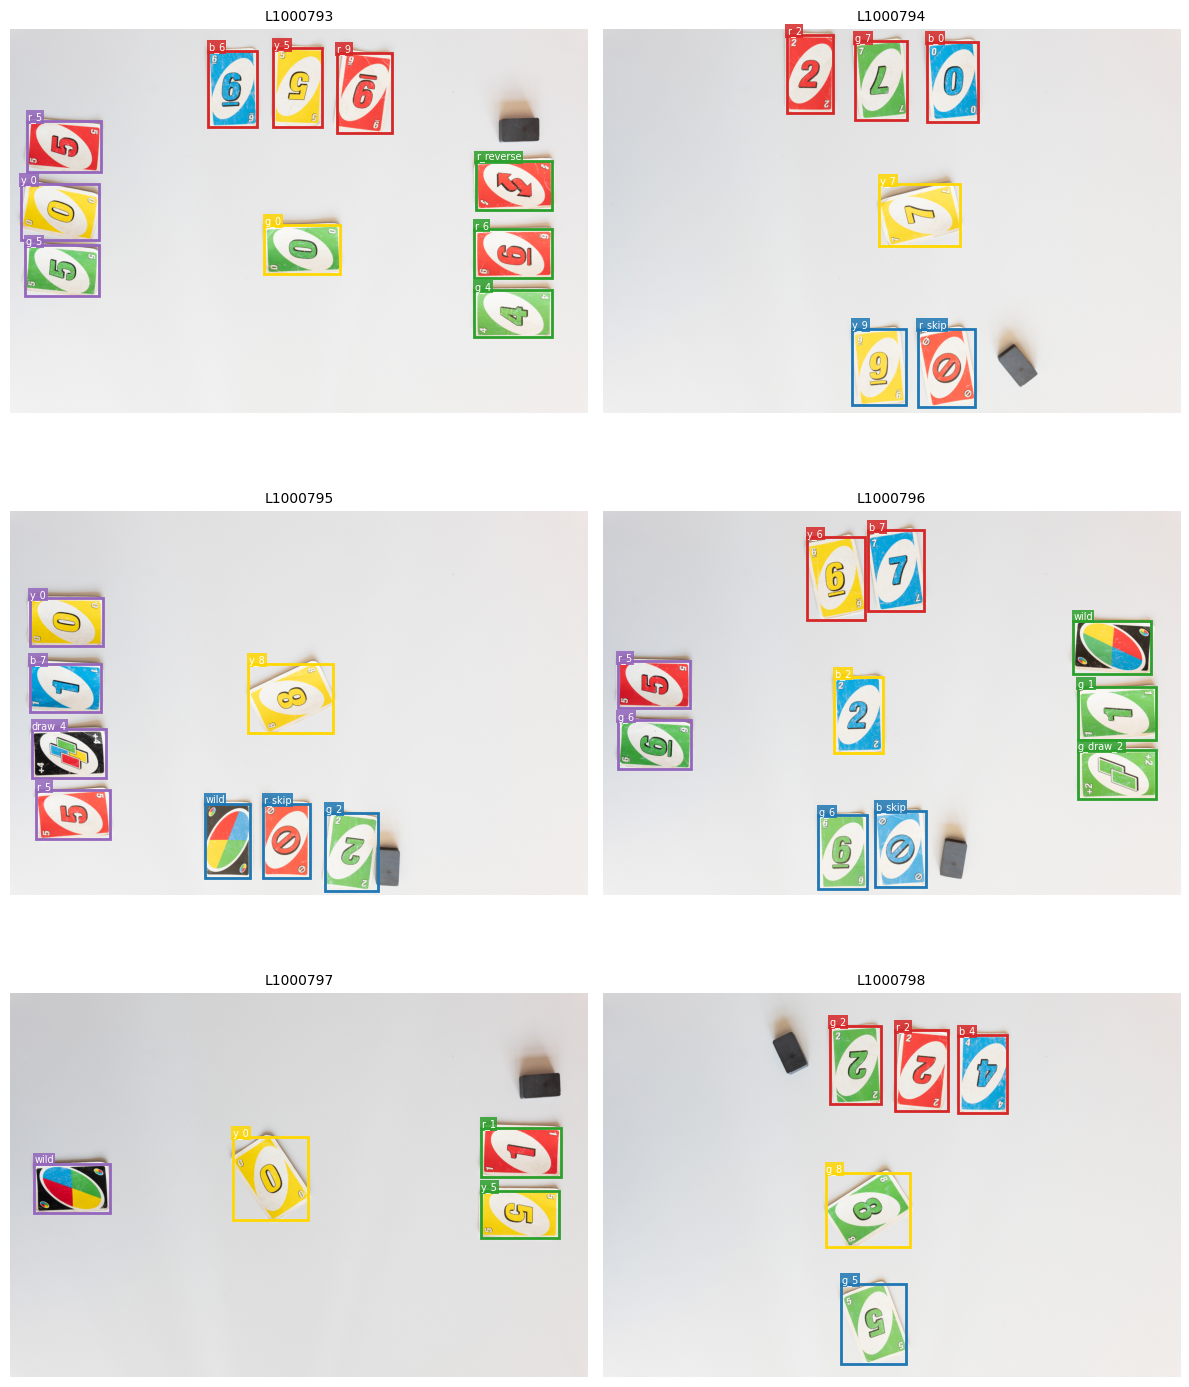

In [ ]:
# Hand-pick a few example IDs after looking at the benchmark output. Replace
# this list with the IDs that best illustrate the failure modes discussed.
showcase_ids = [s.image_id for s in test_states[:6]]
showcase = []
for image_id in showcase_ids:
    state = next((s for s in test_states if s.image_id == image_id), None)
    if state is None:
        continue
    showcase.append((TEST_DIR / f"{image_id}.jpg", state))

plot_qualitative_grid(showcase, cols=2, max_rows=3)

> *Comment:* discuss 2–3 of the qualitative examples in detail.

## 10. Reproducing the Kaggle submission

The submission CSV uploaded to Kaggle is produced by:

```bash
python main.py
```

The cell below performs the same operation from within the notebook so the
report contains a self-contained reproduction.

In [ ]:
submission_path = write_submission(test_states, REPO_ROOT / "submission.csv", validate=True)
print(f"Wrote {submission_path}")
pd.read_csv(submission_path).head()

Wrote C:\Users\doria\Documents\EPFL\IA\iapr2026do\submission.csv


,image_id,center_card,active_player,player_1_cards,player_2_cards,player_3_cards,player_4_cards
0,L1000793,g_0,EMPTY,EMPTY,r_6;r_reverse;g_4,r_9;y_5;b_6,y_0;r_5;g_5
1,L1000794,y_7,EMPTY,r_skip;y_9,EMPTY,g_7;b_0;r_2,EMPTY
2,L1000795,y_8,EMPTY,g_2;r_skip;wild,EMPTY,EMPTY,r_5;draw_4;y_0;b_7
3,L1000796,b_2,EMPTY,b_skip;g_6,wild;g_1;g_draw_2,y_6;b_7,g_6;r_5
4,L1000797,y_0,EMPTY,EMPTY,r_1;y_5,EMPTY,wild


## 11. Limitations and future work

> *Write here:* honest list of what we did not solve, what would be the next
> two improvements (e.g. instance-aware segmentation head, active-player
> token CNN, calibrated confidence-based rejection of low-quality crops).